In [12]:
from kan import KAN, create_dataset
import torch
from torch.utils.data import DataLoader, TensorDataset
from MLP2layers import NeuralNetwork, test_loop, train_loop
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np
from torch import nn

In [13]:
device = 'cpu'
targetModel = NeuralNetwork().to(device)
layers = list(*targetModel.children())
x = torch.linspace(-5,5,steps=500)[:,None].repeat(1,2)
print(targetModel.state_dict())
# x = torch.randn(1000,2)

OrderedDict({'linear_relu_stack.0.weight': tensor([[-0.0053,  0.3793],
        [-0.5820, -0.5204],
        [-0.2723,  0.1896]]), 'linear_relu_stack.0.bias': tensor([-0.0140,  0.5607, -0.0628]), 'linear_relu_stack.2.weight': tensor([[ 0.1528, -0.1745, -0.1135]]), 'linear_relu_stack.2.bias': tensor([-0.5516])})


In [14]:
kan = KAN(width=[2,3,1], seed=42, grid=100, scale_base_sigma=0)

checkpoint directory created: ./model
saving model version 0.0


In [15]:
kan.set_splines(x, modelPartitions=[layers[:1], layers[1:]])

[Linear(in_features=2, out_features=3, bias=True)]
weight: tensor([[-0.0053, -0.5820, -0.2723]], grad_fn=<SliceBackward0>), bias: tensor([[-0.0070,  0.2803, -0.0314]], grad_fn=<SliceBackward0>)
weight: tensor([[ 0.3793, -0.5204,  0.1896]], grad_fn=<SliceBackward0>), bias: tensor([[-0.0070,  0.2803, -0.0314]], grad_fn=<SliceBackward0>)
[ReLU(), Linear(in_features=3, out_features=1, bias=True)]
weight: tensor([[0.1528]], grad_fn=<SliceBackward0>), bias: tensor([[-0.1839]], grad_fn=<SliceBackward0>)
weight: tensor([[-0.1745]], grad_fn=<SliceBackward0>), bias: tensor([[-0.1839]], grad_fn=<SliceBackward0>)
weight: tensor([[-0.1135]], grad_fn=<SliceBackward0>), bias: tensor([[-0.1839]], grad_fn=<SliceBackward0>)


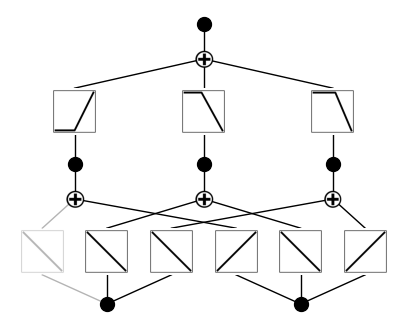

In [16]:
kan.plot(beta=100)

In [17]:
X_kan = torch.randn(10000,2)
y_kan = targetModel(X_kan).detach()
y_kan_mean = y_kan.numpy().mean()
print(X_kan)
print(y_kan_mean)
print(y_kan)

tensor([[-0.5702,  0.3233],
        [-0.1720, -1.3672],
        [ 0.6497, -0.3372],
        ...,
        [ 0.4373,  0.5164],
        [-0.5255, -1.2476],
        [ 1.0535,  0.2364]])
-0.6580442
tensor([[-0.6783],
        [-0.7910],
        [-0.6140],
        ...,
        [-0.5307],
        [-0.8160],
        [-0.5409]])


In [18]:
# X_train, X_test, y_train, y_test = train_test_split(X_kan.detach().numpy(), y_kan.detach().numpy(), test_size=0.2, random_state=42)
# X_train = X_kan.detach().numpy()
# y_train = y_kan.detach().numpy()
# X_test = X_kan.detach().numpy()
# y_test = y_kan.detach().numpy()

# Standardize features
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# Create TensorDatasets and DataLoaders
train_dataset = TensorDataset(X_kan, y_kan)
test_dataset = TensorDataset(X_kan, y_kan)

train_dataLoader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataLoader = DataLoader(test_dataset, batch_size=16, shuffle=False)

device = "cpu"

model = NeuralNetwork().to(device)
print(model)
print(model.state_dict())
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)


epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataLoader, model, loss_fn, optimizer)
    test_loop(test_dataLoader, model, loss_fn)




NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=2, out_features=3, bias=True)
    (1): ReLU()
    (2): Linear(in_features=3, out_features=1, bias=True)
  )
)
OrderedDict({'linear_relu_stack.0.weight': tensor([[-0.5059,  0.2907],
        [-0.2902, -0.6946],
        [-0.0507, -0.3593]]), 'linear_relu_stack.0.bias': tensor([-0.2093, -0.2791, -0.2373]), 'linear_relu_stack.2.weight': tensor([[-0.3759, -0.1172, -0.3639]]), 'linear_relu_stack.2.bias': tensor([-0.0763])})
Epoch 1
-------------------------------
Test loss: 0.006710
Epoch 2
-------------------------------
Test loss: 0.005135
Epoch 3
-------------------------------
Test loss: 0.004357
Epoch 4
-------------------------------
Test loss: 0.003755
Epoch 5
-------------------------------
Test loss: 0.003190
Epoch 6
-------------------------------
Test loss: 0.002612
Epoch 7
-------------------------------
Test loss: 0.002067
Epoch 8
-------------------------------
Test loss: 0.001574
Epoch 9
-------------

In [19]:
model.eval()
y_mlp_pred = model(X_kan).detach()
print(mean_squared_error(y_kan.numpy(), y_mlp_pred.numpy()))

0.00022327108308672905


checkpoint directory created: ./model
saving model version 0.0
[Linear(in_features=2, out_features=3, bias=True)]
weight: tensor([[-0.4825, -0.2859, -0.2281]], grad_fn=<SliceBackward0>), bias: tensor([[-0.0486, -0.0856,  0.1716]], grad_fn=<SliceBackward0>)
weight: tensor([[-0.0829, -0.7225, -0.2687]], grad_fn=<SliceBackward0>), bias: tensor([[-0.0486, -0.0856,  0.1716]], grad_fn=<SliceBackward0>)
[ReLU(), Linear(in_features=3, out_features=1, bias=True)]
weight: tensor([[-0.0777]], grad_fn=<SliceBackward0>), bias: tensor([[-0.1653]], grad_fn=<SliceBackward0>)
weight: tensor([[0.0495]], grad_fn=<SliceBackward0>), bias: tensor([[-0.1653]], grad_fn=<SliceBackward0>)
weight: tensor([[-0.4316]], grad_fn=<SliceBackward0>), bias: tensor([[-0.1653]], grad_fn=<SliceBackward0>)
0.00022335110406856984
0.00033941655


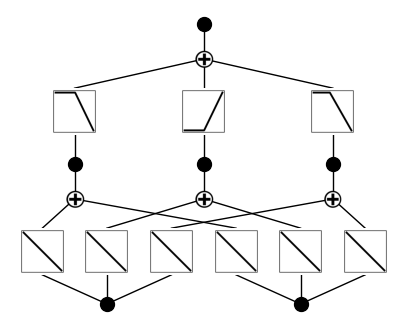

In [20]:
new_layers = list(*model.children())
kan2 = KAN(width=[2,3,1], seed=42, grid=100, scale_base_sigma=0)
kan2.set_splines(x, modelPartitions=[new_layers[:1], new_layers[1:]])
kan2.plot(beta=100)
y_kan2_pred = kan2(X_kan).detach()
kan2_mse = mean_squared_error(y_kan.numpy(), y_kan2_pred.numpy())   
print(kan2_mse)
print(abs(kan2_mse/y_kan_mean))

| train_loss: 5.41e-02 | test_loss: 5.41e-02 | reg: 4.83e+00 | : 100%|█| 20/20 [00:29<00:00,  1.47s/


saving model version 0.1
0.002926657209172845


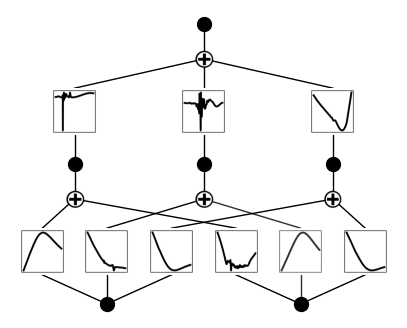

In [21]:
dataset1 = {'train_input':X_kan, 'train_label':y_kan, 'test_input': X_kan, 'test_label':y_kan}
# f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
# dataset = create_dataset(f, n_var=2, device=device)
kan2(dataset1['train_input'])
kan2.fit(dataset1, opt="LBFGS", steps=20, lamb=0.01)
kan2.plot(beta=100)
y_kan2_pred_afterFit = kan2(X_kan).detach()
print(mean_squared_error(y_kan.numpy(), y_kan2_pred_afterFit.numpy()))

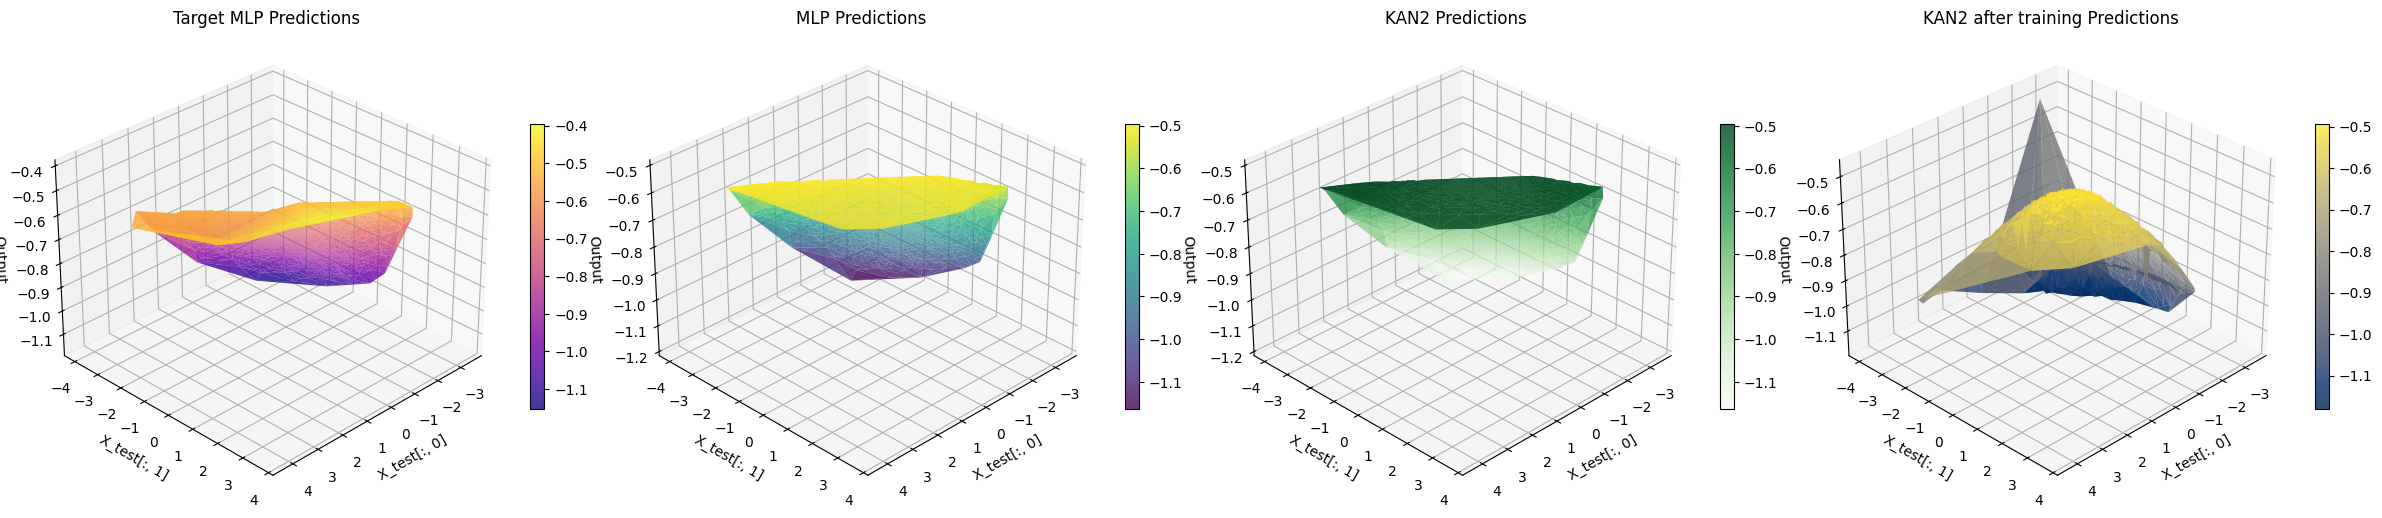

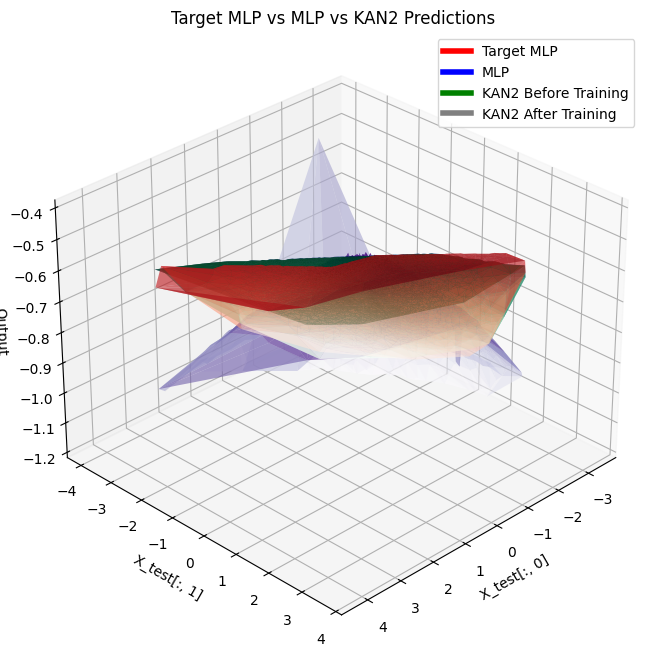

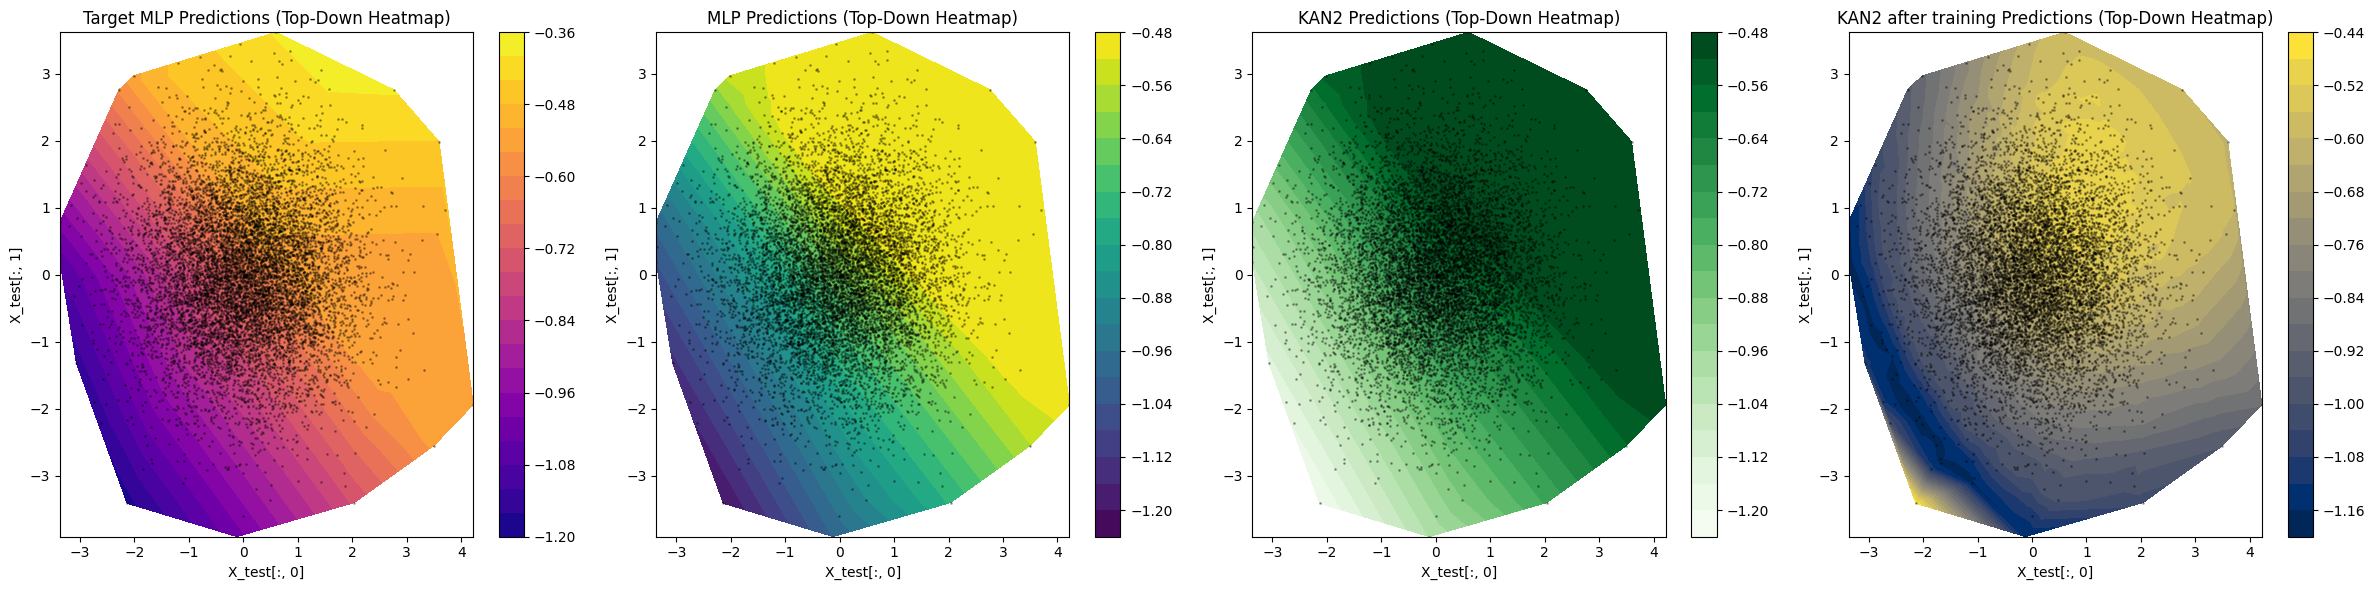

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.lines import Line2D

# Get predictions from both models
X_plot = X_kan.numpy()
y_plot = y_kan.numpy()
model.eval()
with torch.no_grad():
    X_test_tensor = torch.from_numpy(X_plot).float()
    
    y_target_mlp_np = y_plot.flatten()

    y_mlp_pred_np = y_mlp_pred.numpy().flatten()
    y_kan2_pred_np = y_kan2_pred.numpy().flatten()

    y_kan2_pred_afterFit_np = y_kan2_pred_afterFit.numpy().flatten()

# Set viewing angles (in degrees)
elevation = 30  # vertical angle
azimuth = 45    # horizontal rotation

# Use triangulation for scattered data (no griddata)
triang = mtri.Triangulation(X_plot[:, 0], X_plot[:, 1])

# Create surface plots - KAN, MLP, and KAN2
fig = plt.figure(figsize=(24, 6))

# Plot 1: Target MLP predictions
ax1 = fig.add_subplot(141, projection='3d')
surf1 = ax1.plot_trisurf(triang, y_target_mlp_np, cmap='plasma', alpha=0.8, linewidth=0.2, antialiased=True)
ax1.set_xlabel('X_test[:, 0]')
ax1.set_ylabel('X_test[:, 1]')
ax1.set_zlabel('Output')
ax1.set_title('Target MLP Predictions')
ax1.view_init(elev=elevation, azim=azimuth)
fig.colorbar(surf1, ax=ax1, shrink=0.5)

# Plot 2: MLP predictions
ax2 = fig.add_subplot(142, projection='3d')
surf2 = ax2.plot_trisurf(triang, y_mlp_pred_np, cmap='viridis', alpha=0.8, linewidth=0.2, antialiased=True)
ax2.set_xlabel('X_test[:, 0]')
ax2.set_ylabel('X_test[:, 1]')
ax2.set_zlabel('Output')
ax2.set_title('MLP Predictions')
ax2.view_init(elev=elevation, azim=azimuth)
fig.colorbar(surf2, ax=ax2, shrink=0.5)

#plot 3: KAN2 before training predictions
ax3 = fig.add_subplot(143, projection='3d')
surf3 = ax3.plot_trisurf(triang, y_kan2_pred_np, cmap='Greens', alpha=0.8, linewidth=0.2, antialiased=True)
ax3.set_xlabel('X_test[:, 0]')
ax3.set_ylabel('X_test[:, 1]')
ax3.set_zlabel('Output')
ax3.set_title('KAN2 Predictions')
ax3.view_init(elev=elevation, azim=azimuth)
fig.colorbar(surf3, ax=ax3, shrink=0.5)

# Plot 4: KAN2 after training predictions
ax4 = fig.add_subplot(144, projection='3d')
surf4 = ax4.plot_trisurf(triang, y_kan2_pred_afterFit_np, cmap='cividis', alpha=0.8, linewidth=0.2, antialiased=True)
ax4.set_xlabel('X_test[:, 0]')
ax4.set_ylabel('X_test[:, 1]')
ax4.set_zlabel('Output')
ax4.set_title('KAN2 after training Predictions')
ax4.view_init(elev=elevation, azim=azimuth)
fig.colorbar(surf4, ax=ax4, shrink=0.5)

plt.tight_layout()
plt.show()

# Combined plot showing difference (tri-surf overlays)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(triang, y_target_mlp_np, cmap='Reds', alpha=0.6)
ax.plot_trisurf(triang, y_mlp_pred_np, cmap='Blues', alpha=0.6)
ax.plot_trisurf(triang, y_kan2_pred_np, cmap='Greens', alpha=0.6)
ax.plot_trisurf(triang, y_kan2_pred_afterFit_np, cmap='Purples', alpha=0.6)
ax.set_xlabel('X_test[:, 0]')
ax.set_ylabel('X_test[:, 1]')
ax.set_zlabel('Output')
ax.set_title('Target MLP vs MLP vs KAN2 Predictions')
ax.view_init(elev=elevation, azim=azimuth)

# Create custom legend
legend_elements = [
    Line2D([0], [0], color='red', lw=4, label='Target MLP'),
    Line2D([0], [0], color='blue', lw=4, label='MLP'),
    Line2D([0], [0], color='green', lw=4, label='KAN2 Before Training'),
    Line2D([0], [0], color='grey', lw=4, label='KAN2 After Training')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.show()

# Create top-down heatmap views using tricontourf
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24, 6))

# Target MLP heatmap
im1 = ax1.tricontourf(triang, y_target_mlp_np, levels=20, cmap='plasma')
ax1.scatter(X_plot[:, 0], X_plot[:, 1], c='black', s=1, alpha=0.3, label='Data Points')
ax1.set_xlabel('X_test[:, 0]')
ax1.set_ylabel('X_test[:, 1]')
ax1.set_title('Target MLP Predictions (Top-Down Heatmap)')
fig.colorbar(im1, ax=ax1)

# MLP heatmap
im2 = ax2.tricontourf(triang, y_mlp_pred_np, levels=20, cmap='viridis')
ax2.scatter(X_plot[:, 0], X_plot[:, 1], c='black', s=1, alpha=0.3, label='Data Points')
ax2.set_xlabel('X_test[:, 0]')
ax2.set_ylabel('X_test[:, 1]')
ax2.set_title('MLP Predictions (Top-Down Heatmap)')
fig.colorbar(im2, ax=ax2)

# KAN2 heatmap
im3 = ax3.tricontourf(triang, y_kan2_pred_np, levels=20, cmap='Greens')
ax3.scatter(X_plot[:, 0], X_plot[:, 1], c='black', s=1, alpha=0.3, label='Data Points')
ax3.set_xlabel('X_test[:, 0]')
ax3.set_ylabel('X_test[:, 1]')
ax3.set_title('KAN2 Predictions (Top-Down Heatmap)')
fig.colorbar(im3, ax=ax3)

# KAN2 after training heatmap
im4 = ax4.tricontourf(triang, y_kan2_pred_afterFit_np, levels=20, cmap='cividis')
ax4.scatter(X_plot[:, 0], X_plot[:, 1], c='black', s=1, alpha=0.3, label='Data Points')
ax4.set_xlabel('X_test[:, 0]')
ax4.set_ylabel('X_test[:, 1]')
ax4.set_title('KAN2 after training Predictions (Top-Down Heatmap)')
fig.colorbar(im4, ax=ax4)

plt.tight_layout()
plt.show()
